# Demo ADASYN 

## Import và cấu hình pipeline

In [1]:
from pathlib import Path
import sys

from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

PROJECT_ROOT = Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_preprocessing import (
    RANDOM_STATE,
    TEST_SIZE,
    build_leakage_checklist,
    make_features_target,
    preprocess_train_test,
    split_data,
    split_feature_types,
)

print(f"Thư mục project = {PROJECT_ROOT}")
print(f"Tỉ lệ test = {TEST_SIZE}")
print(f"Random state = {RANDOM_STATE}")

Thư mục project = D:\Adasync-Data-Mining
Tỉ lệ test = 0.2
Random state = 42


## Quang - Load data và kiểm tra dữ liệu đầu vào

In [2]:
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "uci_wdbc" / "wdbc.data"

WDBC_COLUMNS = [
    "id",
    "diagnosis",
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "smoothness_mean",
    "compactness_mean",
    "concavity_mean",
    "concave_points_mean",
    "symmetry_mean",
    "fractal_dimension_mean",
    "radius_se",
    "texture_se",
    "perimeter_se",
    "area_se",
    "smoothness_se",
    "compactness_se",
    "concavity_se",
    "concave_points_se",
    "symmetry_se",
    "fractal_dimension_se",
    "radius_worst",
    "texture_worst",
    "perimeter_worst",
    "area_worst",
    "smoothness_worst",
    "compactness_worst",
    "concavity_worst",
    "concave_points_worst",
    "symmetry_worst",
    "fractal_dimension_worst",
]

ID_COLUMN = "id"
TARGET_COLUMN = "diagnosis"
FEATURE_COLUMNS = [column for column in WDBC_COLUMNS if column not in [ID_COLUMN, TARGET_COLUMN]]

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset file not found: {DATA_PATH}")

df = pd.read_csv(DATA_PATH, header=None, names=WDBC_COLUMNS)
df[FEATURE_COLUMNS] = df[FEATURE_COLUMNS].apply(pd.to_numeric, errors="coerce")

missing_values = df.isna().sum()
numeric_feature_count = df[FEATURE_COLUMNS].select_dtypes(include="number").shape[1]

input_summary = pd.DataFrame(
    {
        "metric": [
            "rows",
            "columns",
            "feature columns",
            "numeric feature columns",
            "target column",
            "total missing values",
        ],
        "value": [
            df.shape[0],
            df.shape[1],
            len(FEATURE_COLUMNS),
            numeric_feature_count,
            TARGET_COLUMN,
            int(missing_values.sum()),
        ],
    }
)

target_preview = df[TARGET_COLUMN].value_counts().rename_axis("class").reset_index(name="count")

print(f"Đã tải dataset từ: {DATA_PATH}")
print(f"Kích thước dữ liệu: {df.shape[0]} dòng x {df.shape[1]} cột")
print(f"Cột target: {TARGET_COLUMN}")
print(f"Số cột feature: {len(FEATURE_COLUMNS)}")
print(f"Tổng số missing values: {int(missing_values.sum())}")

display(input_summary)
display(target_preview)
display(df.head())

Đã tải dataset từ: D:\Adasync-Data-Mining\data\raw\uci_wdbc\wdbc.data
Kích thước dữ liệu: 569 dòng x 32 cột
Cột target: diagnosis
Số cột feature: 30
Tổng số missing values: 0


,metric,value
0,rows,569
1,columns,32
2,feature columns,30
3,numeric feature columns,30
4,target column,diagnosis
5,total missing values,0


,class,count
0,B,357
1,M,212


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Quang - EDA và class distribution

Lớp đa số: B (357 mẫu)
Lớp thiểu số: M (212 mẫu)
Tỉ lệ đa số/thiểu số: 1.68:1


,class,count,label,percentage,class_type
0,B,357,Benign,62.74,Majority
1,M,212,Malignant,37.26,Minority


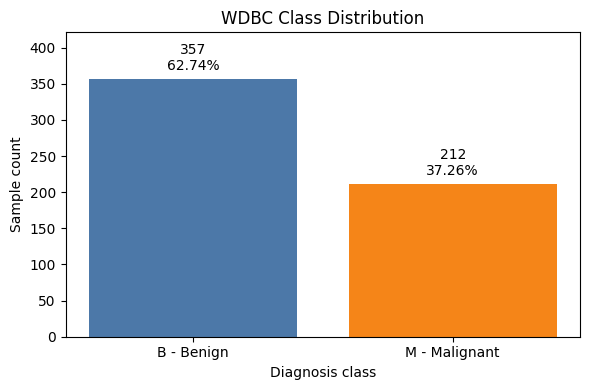

Đã lưu biểu đồ phân phối class vào: D:\Adasync-Data-Mining\results\class_distribution.png


In [3]:
required_names = ["df", "TARGET_COLUMN"]
missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise NameError(f"Missing variables from load-data cell: {missing_names}")

CLASS_LABELS = {"M": "Malignant", "B": "Benign"}

class_distribution = (
    df[TARGET_COLUMN]
    .value_counts()
    .rename_axis("class")
    .reset_index(name="count")
)
class_distribution["label"] = class_distribution["class"].map(CLASS_LABELS)
class_distribution["percentage"] = (class_distribution["count"] / len(df) * 100).round(2)

majority_index = class_distribution["count"].idxmax()
minority_index = class_distribution["count"].idxmin()
majority_class = class_distribution.loc[majority_index, "class"]
minority_class = class_distribution.loc[minority_index, "class"]
majority_count = int(class_distribution.loc[majority_index, "count"])
minority_count = int(class_distribution.loc[minority_index, "count"])
class_ratio = round(majority_count / minority_count, 2)

class_distribution["class_type"] = class_distribution["class"].map(
    {majority_class: "Majority", minority_class: "Minority"}
)

print(f"Lớp đa số: {majority_class} ({majority_count} mẫu)")
print(f"Lớp thiểu số: {minority_class} ({minority_count} mẫu)")
print(f"Tỉ lệ đa số/thiểu số: {class_ratio}:1")

display(class_distribution)

import matplotlib.pyplot as plt

RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)
class_distribution_path = RESULTS_DIR / "class_distribution.png"

plot_labels = class_distribution["class"] + " - " + class_distribution["label"]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(plot_labels, class_distribution["count"], color=["#4C78A8", "#F58518"])
ax.set_title("WDBC Class Distribution")
ax.set_xlabel("Diagnosis class")
ax.set_ylabel("Sample count")
ax.set_ylim(0, class_distribution["count"].max() * 1.18)

for bar, percentage in zip(bars, class_distribution["percentage"]):
    height = bar.get_height()
    ax.annotate(
        f"{int(height)}\n{percentage:.2f}%",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 4),
        textcoords="offset points",
        ha="center",
        va="bottom",
    )

fig.tight_layout()
fig.savefig(class_distribution_path, dpi=150, bbox_inches="tight")
if plt.get_backend().lower() == "agg":
    plt.close(fig)
else:
    plt.show()

print(f"Đã lưu biểu đồ phân phối class vào: {class_distribution_path}")

## Phúc - Train/test split chuẩn

In [4]:
# - df: DataFrame dữ liệu đã load
# - FEATURE_COLUMNS: danh sách cột feature, đã loại id và target
# - TARGET_COLUMN: tên cột target

required_names = ["df", "FEATURE_COLUMNS", "TARGET_COLUMN"]
missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise NameError(f"Thiếu biến đầu vào từ phần Quang: {missing_names}")

X, y = make_features_target(df, FEATURE_COLUMNS, TARGET_COLUMN)
numeric_feature_columns, categorical_feature_columns = split_feature_types(X)
missing_by_feature = X.isna().sum()

feature_input_summary = pd.DataFrame(
    {
        "item": [
            "Feature columns used for training",
            "Numeric feature columns",
            "Categorical feature columns",
            "Total missing values before split",
            "Columns with missing values",
            "ID column excluded from training",
        ],
        "value": [
            X.shape[1],
            len(numeric_feature_columns),
            len(categorical_feature_columns),
            int(missing_by_feature.sum()),
            int((missing_by_feature > 0).sum()),
            ID_COLUMN not in X.columns if "ID_COLUMN" in globals() else "id" not in X.columns,
        ],
    }
)

display(feature_input_summary)

X_train, X_test, y_train, y_test = split_data(X, y)

def make_class_distribution(name, labels):
    distribution = (
        labels.value_counts()
        .rename_axis("class")
        .reset_index(name="count")
    )
    distribution["dataset"] = name
    distribution["percentage"] = (distribution["count"] / len(labels) * 100).round(2)
    return distribution[["dataset", "class", "count", "percentage"]]

class_distribution_train_test = pd.concat(
    [
        make_class_distribution("full", y),
        make_class_distribution("train", y_train),
        make_class_distribution("test", y_test),
    ],
    ignore_index=True,
)

if "CLASS_LABELS" in globals():
    class_distribution_train_test.insert(
        2,
        "label",
        class_distribution_train_test["class"].map(CLASS_LABELS),
    )

RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)
train_test_class_distribution_path = RESULTS_DIR / "train_test_class_distribution.csv"
class_distribution_train_test.to_csv(train_test_class_distribution_path, index=False)

display(class_distribution_train_test)

assert set(X_train.index).isdisjoint(set(X_test.index)), "Train/test indices bị trùng."

print(f"Chia dữ liệu: train={1 - TEST_SIZE:.0%}, test={TEST_SIZE:.0%}, stratify=y, random_state={RANDOM_STATE}")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"Đã lưu tỉ lệ class vào: {train_test_class_distribution_path}")

,item,value
0,Feature columns used for training,30
1,Numeric feature columns,30
2,Categorical feature columns,0
3,Total missing values before split,0
4,Columns with missing values,0
5,ID column excluded from training,True


,dataset,class,label,count,percentage
0,full,B,Benign,357,62.74
1,full,M,Malignant,212,37.26
2,train,B,Benign,285,62.64
3,train,M,Malignant,170,37.36
4,test,B,Benign,72,63.16
5,test,M,Malignant,42,36.84


Chia dữ liệu: train=80%, test=20%, stratify=y, random_state=42
X_train: (455, 30)
X_test: (114, 30)
Đã lưu tỉ lệ class vào: D:\Adasync-Data-Mining\results\train_test_class_distribution.csv


## Phúc - Preprocessing sau train/test split

In [5]:
required_names = [
    "X_train",
    "X_test",
    "numeric_feature_columns",
    "categorical_feature_columns",
    "missing_by_feature",
]
missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise NameError(f"Thiếu biến đầu vào từ cell train/test split: {missing_names}")

if categorical_feature_columns:
    categorical_summary = pd.DataFrame(
        {
            "feature": categorical_feature_columns,
            "dtype": X_train[categorical_feature_columns].dtypes.astype(str).values,
        }
    )
    print("Có feature dạng phân loại; pipeline sẽ impute theo mode và One-Hot Encode trên train set.")
    display(categorical_summary)
else:
    print("Không có feature dạng phân loại trong X; WDBC chỉ có feature số nên không cần encode.")

if missing_by_feature.sum() > 0:
    missing_summary = (
        missing_by_feature[missing_by_feature > 0]
        .rename_axis("feature")
        .reset_index(name="missing_count")
    )
    display(missing_summary)
else:
    print("Không có missing values trước khi split; vẫn giữ SimpleImputer trong pipeline để đúng quy định.")

X_train_processed, X_test_processed, preprocessor = preprocess_train_test(X_train, X_test)

assert X_train_processed.isna().sum().sum() == 0, "Train sau preprocessing vẫn còn missing."
assert X_test_processed.isna().sum().sum() == 0, "Test sau preprocessing vẫn còn missing."
assert X_train_processed.columns.equals(X_test_processed.columns), "Train/test processed columns không khớp."

print("Preprocessing fit trên train set và transform train/test.")
print(f"Số numeric features: {len(numeric_feature_columns)}")
print(f"Số categorical features: {len(categorical_feature_columns)}")
print(f"X_train_processed: {X_train_processed.shape}")
print(f"X_test_processed: {X_test_processed.shape}")

Không có feature dạng phân loại trong X; WDBC chỉ có feature số nên không cần encode.
Không có missing values trước khi split; vẫn giữ SimpleImputer trong pipeline để đúng quy định.
Preprocessing fit trên train set và transform train/test.
Số numeric features: 30
Số categorical features: 0
X_train_processed: (455, 30)
X_test_processed: (114, 30)


## Quân - Baseline, Random Oversampling, Random Undersampling

In [6]:
required_names = ["X_train_processed", "X_test_processed", "y_train", "y_test"]
missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise NameError(f"Thiếu biến đầu vào cho baseline/ROS/RUS: {missing_names}")

POSITIVE_CLASS = "M"
CONFUSION_MATRIX_LABELS = ["B", "M"]

DETAIL_METRIC_COLUMNS = ["precision", "recall", "f1_score", "roc_auc", "average_precision"]
REPORT_SCHEMA = ["Method", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"]
REPORT_METRIC_COLUMNS = ["Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"]

x_test_index_before_sampling = X_test_processed.index.copy()
y_test_index_before_sampling = y_test.index.copy()
x_test_rows_before_sampling = len(X_test_processed)
y_test_positive = (y_test == POSITIVE_CLASS).astype(int)


def build_logistic_regression_model():
    return LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)


def make_method_metrics(method, resampling, model, train_rows, y_pred, y_score):
    return pd.DataFrame(
        [
            {
                "method": method,
                "resampling": resampling,
                "model": "LogisticRegression",
                "train_rows": train_rows,
                "test_rows": len(X_test_processed),
                "positive_class": POSITIVE_CLASS,
                "precision": round(precision_score(y_test, y_pred, pos_label=POSITIVE_CLASS), 4),
                "recall": round(recall_score(y_test, y_pred, pos_label=POSITIVE_CLASS), 4),
                "f1_score": round(f1_score(y_test, y_pred, pos_label=POSITIVE_CLASS), 4),
                "roc_auc": round(roc_auc_score(y_test_positive, y_score), 4),
                "average_precision": round(average_precision_score(y_test_positive, y_score), 4),
            }
        ]
    )


def predict_positive_scores(model, X):
    positive_class_index = list(model.classes_).index(POSITIVE_CLASS)
    return model.predict_proba(X)[:, positive_class_index]


def make_confusion_matrix_df(matrix):
    return pd.DataFrame(
        matrix,
        index=[f"actual_{label}" for label in CONFUSION_MATRIX_LABELS],
        columns=[f"pred_{label}" for label in CONFUSION_MATRIX_LABELS],
    )


def make_train_class_distribution(dataset_name, labels):
    distribution = labels.value_counts().rename_axis("class").reset_index(name="count")
    distribution["dataset"] = dataset_name
    distribution["label"] = distribution["class"].map(CLASS_LABELS)
    distribution["percentage"] = (distribution["count"] / len(labels) * 100).round(2)
    return distribution[["dataset", "class", "label", "count", "percentage"]]


def to_report_metrics(metrics_detail):
    report_metrics = metrics_detail.rename(
        columns={
            "method": "Method",
            "precision": "Precision",
            "recall": "Recall",
            "f1_score": "F1-score",
            "roc_auc": "ROC-AUC",
            "average_precision": "PR-AUC",
        }
    )
    return report_metrics[REPORT_SCHEMA]


def save_metrics_comparison(metrics_df, output_path):
    try:
        metrics_df.to_csv(output_path, index=False)
    except PermissionError as exc:
        raise PermissionError(
            f"Không thể ghi {output_path}. Hãy đóng file CSV nếu đang mở trong Excel, VS Code hoặc ứng dụng khác, rồi chạy lại cell này."
        ) from exc


baseline_model = build_logistic_regression_model()
baseline_model.fit(X_train_processed, y_train)
baseline_y_pred = baseline_model.predict(X_test_processed)
baseline_y_score = predict_positive_scores(baseline_model, X_test_processed)
baseline_metrics = make_method_metrics(
    method="Baseline",
    resampling="No resampling",
    model=baseline_model,
    train_rows=len(X_train_processed),
    y_pred=baseline_y_pred,
    y_score=baseline_y_score,
)
baseline_confusion_matrix = confusion_matrix(
    y_test,
    baseline_y_pred,
    labels=CONFUSION_MATRIX_LABELS,
)
baseline_confusion_matrix_df = make_confusion_matrix_df(baseline_confusion_matrix)

ros_sampler = RandomOverSampler(random_state=RANDOM_STATE)
X_train_ros, y_train_ros = ros_sampler.fit_resample(X_train_processed, y_train)
ros_model = build_logistic_regression_model()
ros_model.fit(X_train_ros, y_train_ros)
ros_y_pred = ros_model.predict(X_test_processed)
ros_y_score = predict_positive_scores(ros_model, X_test_processed)
ros_metrics = make_method_metrics(
    method="Random Oversampling",
    resampling="RandomOverSampler",
    model=ros_model,
    train_rows=len(X_train_ros),
    y_pred=ros_y_pred,
    y_score=ros_y_score,
)
ros_confusion_matrix = confusion_matrix(
    y_test,
    ros_y_pred,
    labels=CONFUSION_MATRIX_LABELS,
)
ros_confusion_matrix_df = make_confusion_matrix_df(ros_confusion_matrix)

rus_sampler = RandomUnderSampler(random_state=RANDOM_STATE)
X_train_rus, y_train_rus = rus_sampler.fit_resample(X_train_processed, y_train)
rus_model = build_logistic_regression_model()
rus_model.fit(X_train_rus, y_train_rus)
rus_y_pred = rus_model.predict(X_test_processed)
rus_y_score = predict_positive_scores(rus_model, X_test_processed)
rus_metrics = make_method_metrics(
    method="Random Undersampling",
    resampling="RandomUnderSampler",
    model=rus_model,
    train_rows=len(X_train_rus),
    y_pred=rus_y_pred,
    y_score=rus_y_score,
)
rus_confusion_matrix = confusion_matrix(
    y_test,
    rus_y_pred,
    labels=CONFUSION_MATRIX_LABELS,
)
rus_confusion_matrix_df = make_confusion_matrix_df(rus_confusion_matrix)

sampling_train_class_distribution = pd.concat(
    [
        make_train_class_distribution("train_original", y_train),
        make_train_class_distribution("train_ros", y_train_ros),
        make_train_class_distribution("train_rus", y_train_rus),
    ],
    ignore_index=True,
)

assert y_train_ros.value_counts().to_dict() == {"B": 285, "M": 285}
assert y_train_rus.value_counts().to_dict() == {"B": 170, "M": 170}
assert len(X_train_ros) == 570
assert len(X_train_rus) == 340
assert len(X_test_processed) == x_test_rows_before_sampling == 114
assert X_test_processed.index.equals(x_test_index_before_sampling)
assert y_test.index.equals(y_test_index_before_sampling)

basic_sampling_metrics_detail = pd.concat(
    [baseline_metrics, ros_metrics, rus_metrics],
    ignore_index=True,
)
metrics_comparison = to_report_metrics(basic_sampling_metrics_detail)
basic_sampling_metrics = metrics_comparison.copy()

assert basic_sampling_metrics_detail[DETAIL_METRIC_COLUMNS].apply(lambda series: series.between(0, 1).all()).all()
assert list(metrics_comparison.columns) == REPORT_SCHEMA
assert metrics_comparison[REPORT_METRIC_COLUMNS].apply(lambda series: series.between(0, 1).all()).all()
assert metrics_comparison["Method"].tolist() == ["Baseline", "Random Oversampling", "Random Undersampling"]

RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)
metrics_comparison_path = RESULTS_DIR / "metrics_comparison.csv"
save_metrics_comparison(metrics_comparison, metrics_comparison_path)

print("Phân phối class train để kiểm tra resampling:")
display(sampling_train_class_distribution)
print("Bảng metric:")
display(metrics_comparison)
display(baseline_confusion_matrix_df)
display(ros_confusion_matrix_df)
display(rus_confusion_matrix_df)
print("Báo cáo phân loại cho Baseline:")
print(classification_report(y_test, baseline_y_pred, labels=CONFUSION_MATRIX_LABELS))
print("Báo cáo phân loại cho Random Oversampling:")
print(classification_report(y_test, ros_y_pred, labels=CONFUSION_MATRIX_LABELS))
print("Báo cáo phân loại cho Random Undersampling:")
print(classification_report(y_test, rus_y_pred, labels=CONFUSION_MATRIX_LABELS))



Phân phối class train để kiểm tra resampling:


,dataset,class,label,count,percentage
0,train_original,B,Benign,285,62.64
1,train_original,M,Malignant,170,37.36
2,train_ros,M,Malignant,285,50.00
3,train_ros,B,Benign,285,50.00
4,train_rus,B,Benign,170,50.00
5,train_rus,M,Malignant,170,50.00


Bảng metric:


,Method,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Baseline,0.9750,0.9286,0.9512,0.9960,0.9943
1,Random Oversampling,0.9756,0.9524,0.9639,0.9964,0.9949
2,Random Undersampling,0.9756,0.9524,0.9639,0.9950,0.9930


,pred_B,pred_M
actual_B,71,1
actual_M,3,39


,pred_B,pred_M
actual_B,71,1
actual_M,2,40


,pred_B,pred_M
actual_B,71,1
actual_M,2,40


Báo cáo phân loại cho Baseline:
              precision    recall  f1-score   support

           B       0.96      0.99      0.97        72
           M       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

Báo cáo phân loại cho Random Oversampling:
              precision    recall  f1-score   support

           B       0.97      0.99      0.98        72
           M       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

Báo cáo phân loại cho Random Undersampling:
              precision    recall  f1-score   support

           B       0.97      0.99      0.98        72
           M       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro 

## Phước - SMOTE, ADASYN và thử `k_neighbors`

In [7]:
#
from imblearn.over_sampling import SMOTE, ADASYN


smote_sampler = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote_sampler.fit_resample(X_train_processed, y_train)

smote_model = build_logistic_regression_model()
smote_model.fit(X_train_smote, y_train_smote)
smote_y_pred = smote_model.predict(X_test_processed)
smote_y_score = predict_positive_scores(smote_model, X_test_processed)

smote_metrics = make_method_metrics(
    method="SMOTE",
    resampling="SMOTE",
    model=smote_model,
    train_rows=len(X_train_smote),
    y_pred=smote_y_pred,
    y_score=smote_y_score,
)
smote_confusion_matrix = confusion_matrix(y_test, smote_y_pred, labels=CONFUSION_MATRIX_LABELS)
smote_confusion_matrix_df = make_confusion_matrix_df(smote_confusion_matrix)


adasyn_sampler = ADASYN(random_state=RANDOM_STATE) # mặc định n_neighbors=5
X_train_adasyn, y_train_adasyn = adasyn_sampler.fit_resample(X_train_processed, y_train)

adasyn_model = build_logistic_regression_model()
adasyn_model.fit(X_train_adasyn, y_train_adasyn)
adasyn_y_pred = adasyn_model.predict(X_test_processed)
adasyn_y_score = predict_positive_scores(adasyn_model, X_test_processed)

adasyn_metrics = make_method_metrics(
    method="ADASYN",
    resampling="ADASYN",
    model=adasyn_model,
    train_rows=len(X_train_adasyn),
    y_pred=adasyn_y_pred,
    y_score=adasyn_y_score,
)
adasyn_confusion_matrix = confusion_matrix(y_test, adasyn_y_pred, labels=CONFUSION_MATRIX_LABELS)
adasyn_confusion_matrix_df = make_confusion_matrix_df(adasyn_confusion_matrix)


adasyn_k3_sampler = ADASYN(random_state=RANDOM_STATE, n_neighbors=3)
X_train_adasyn_k3, y_train_adasyn_k3 = adasyn_k3_sampler.fit_resample(X_train_processed, y_train)

adasyn_model_k3 = build_logistic_regression_model()
adasyn_model_k3.fit(X_train_adasyn_k3, y_train_adasyn_k3)
adasyn_y_pred_k3 = adasyn_model_k3.predict(X_test_processed)
adasyn_y_score_k3 = predict_positive_scores(adasyn_model_k3, X_test_processed)

adasyn_k3_metrics = make_method_metrics(
    method="ADASYN (k=3)", 
    resampling="ADASYN", 
    model=adasyn_model_k3,
    train_rows=len(X_train_adasyn_k3), 
    y_pred=adasyn_y_pred_k3, 
    y_score=adasyn_y_score_k3
)
adasyn_k3_cm_df = make_confusion_matrix_df(confusion_matrix(y_test, adasyn_y_pred_k3, labels=CONFUSION_MATRIX_LABELS))

# Thử k = 7
adasyn_k7_sampler = ADASYN(random_state=RANDOM_STATE, n_neighbors=7)
X_train_adasyn_k7, y_train_adasyn_k7 = adasyn_k7_sampler.fit_resample(X_train_processed, y_train)

adasyn_model_k7 = build_logistic_regression_model()
adasyn_model_k7.fit(X_train_adasyn_k7, y_train_adasyn_k7)
adasyn_y_pred_k7 = adasyn_model_k7.predict(X_test_processed)
adasyn_y_score_k7 = predict_positive_scores(adasyn_model_k7, X_test_processed)

adasyn_k7_metrics = make_method_metrics(
    method="ADASYN (k=7)", 
    resampling="ADASYN", 
    model=adasyn_model_k7,
    train_rows=len(X_train_adasyn_k7), 
    y_pred=adasyn_y_pred_k7, 
    y_score=adasyn_y_score_k7
)
adasyn_k7_cm_df = make_confusion_matrix_df(confusion_matrix(y_test, adasyn_y_pred_k7, labels=CONFUSION_MATRIX_LABELS))


advanced_sampling_train_class_distribution = pd.concat(
    [
        make_train_class_distribution("train_smote", y_train_smote),
        make_train_class_distribution("train_adasyn", y_train_adasyn),
        make_train_class_distribution("train_adasyn_k3", y_train_adasyn_k3),
        make_train_class_distribution("train_adasyn_k7", y_train_adasyn_k7),
    ],
    ignore_index=True,
)

all_metrics_detail = pd.concat(
    [
        smote_metrics,                 # Kết quả SMOTE
        adasyn_metrics,                # Kết quả ADASYN (k=5)
        adasyn_k3_metrics,             # Kết quả ADASYN (k=3)
        adasyn_k7_metrics              # Kết quả ADASYN (k=7)
    ],
    ignore_index=True,
)

metrics_comparison = to_report_metrics(all_metrics_detail)
save_metrics_comparison(metrics_comparison, metrics_comparison_path)

print("Phân phối class train để kiểm tra resampling (SMOTE & ADASYN):")
display(advanced_sampling_train_class_distribution)

print("Bảng metric tổng hợp:")
display(metrics_comparison)

print("Ma trận nhầm lẫn cho SMOTE:")
display(smote_confusion_matrix_df)

print("Ma trận nhầm lẫn cho ADASYN (k=5):")
display(adasyn_confusion_matrix_df)

print("Ma trận nhầm lẫn cho ADASYN (k=3):")
display(adasyn_k3_cm_df)

print("Ma trận nhầm lẫn cho ADASYN (k=7):")
display(adasyn_k7_cm_df)

print("Báo cáo phân loại cho SMOTE:")
print(classification_report(y_test, smote_y_pred, labels=CONFUSION_MATRIX_LABELS))

print("Báo cáo phân loại cho ADASYN (k=5):")
print(classification_report(y_test, adasyn_y_pred, labels=CONFUSION_MATRIX_LABELS))

print("Báo cáo phân loại cho ADASYN (k=3):")
print(classification_report(y_test, adasyn_y_pred_k3, labels=CONFUSION_MATRIX_LABELS))

print("Báo cáo phân loại cho ADASYN (k=7):")
print(classification_report(y_test, adasyn_y_pred_k7, labels=CONFUSION_MATRIX_LABELS))

Phân phối class train để kiểm tra resampling (SMOTE & ADASYN):


,dataset,class,label,count,percentage
0,train_smote,M,Malignant,285,50.00
1,train_smote,B,Benign,285,50.00
2,train_adasyn,B,Benign,285,51.08
3,train_adasyn,M,Malignant,273,48.92
4,train_adasyn_k3,M,Malignant,287,50.17
5,train_adasyn_k3,B,Benign,285,49.83
6,train_adasyn_k7,M,Malignant,292,50.61
7,train_adasyn_k7,B,Benign,285,49.39


Bảng metric tổng hợp:


,Method,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,SMOTE,0.9756,0.9524,0.9639,0.9927,0.9896
1,ADASYN,0.9756,0.9524,0.9639,0.9831,0.9803
2,ADASYN (k=3),0.9756,0.9524,0.9639,0.9851,0.9825
3,ADASYN (k=7),0.9756,0.9524,0.9639,0.9861,0.9836


Ma trận nhầm lẫn cho SMOTE:


...

Ma trận nhầm lẫn cho ADASYN (k=3):


,pred_B,pred_M
actual_B,71,1
actual_M,2,40


Ma trận nhầm lẫn cho ADASYN (k=7):


,pred_B,pred_M
actual_B,71,1
actual_M,2,40


Báo cáo phân loại cho SMOTE:
              precision    recall  f1-score   support

           B       0.97      0.99      0.98        72
           M       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

Báo cáo phân loại cho ADASYN (k=5):
              precision    recall  f1-score   support

           B       0.97      0.99      0.98        72
           M       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

Báo cáo phân loại cho ADASYN (k=3):
              precision    recall  f1-score   support

           B       0.97      0.99      0.98        72
           M       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97    

## Quyên - Metrics, confusion matrix và biểu đồ so sánh

In [13]:
import pandas as pd
from pathlib import Path
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

RESULTS_DIR = Path(PROJECT_ROOT) / "results" if "PROJECT_ROOT" in globals() else Path.cwd() / "results"
RESULTS_DIR.mkdir(exist_ok=True)
metrics_comparison_path = RESULTS_DIR / "metrics_comparison.csv"

MODEL_NAMES = [
    "baseline_model",
    "ros_model",
    "rus_model",
    "smote_model",
    "adasyn_model",
]
TARGET_METHODS = [
    "Baseline",
    "ROS",
    "RUS",
    "SMOTE",
    "ADASYN",
]


def calculate_all_metrics_from_model(model, X_test, y_test, method):
    positive_class_index = list(model.classes_).index(POSITIVE_CLASS)
    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test)[:, positive_class_index]
    return {
        "Method": method,
        "Precision": round(precision_score(y_test, y_pred, pos_label=POSITIVE_CLASS), 4),
        "Recall": round(recall_score(y_test, y_pred, pos_label=POSITIVE_CLASS), 4),
        "F1-score": round(f1_score(y_test, y_pred, pos_label=POSITIVE_CLASS), 4),
        "ROC-AUC": round(roc_auc_score((y_test == POSITIVE_CLASS).astype(int), y_score), 4),
        "PR-AUC": round(average_precision_score((y_test == POSITIVE_CLASS).astype(int), y_score), 4),
    }

if all(name in globals() for name in MODEL_NAMES) and "X_test_processed" in globals() and "y_test" in globals():
    df_metrics = pd.DataFrame(
        [
            calculate_all_metrics_from_model(globals()[model_name], X_test_processed, y_test, method)
            for model_name, method in zip(MODEL_NAMES, TARGET_METHODS)
        ]
    )
    print("Đã tính metrics cho Baseline, ROS, RUS, SMOTE và ADASYN từ các model hiện có.")
elif metrics_comparison_path.exists():
    df_metrics = pd.read_csv(metrics_comparison_path)
    df_metrics = df_metrics[df_metrics["Method"].isin(TARGET_METHODS)].reset_index(drop=True)
    print(f"Đã đọc bảng metrics từ file: {metrics_comparison_path}")
else:
    raise NameError(
        "Không đủ dữ liệu để tổng hợp metrics. Hãy chạy lại các cell trước đó để đảm bảo các model và dữ liệu test đã sẵn sàng."
    )

save_metrics_comparison(df_metrics, metrics_comparison_path)
print(f"Đã lưu bảng metrics chính vào: {metrics_comparison_path}")

print("--- Tổng hợp bảng metric ---")
display(df_metrics)


Đã tính metrics cho Baseline, ROS, RUS, SMOTE và ADASYN từ các model hiện có.
Đã lưu bảng metrics chính vào: D:\Adasync-Data-Mining\results\metrics_comparison.csv
--- Tổng hợp bảng metric ---


,Method,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Baseline,0.9750,0.9286,0.9512,0.9960,0.9943
1,ROS,0.9756,0.9524,0.9639,0.9964,0.9949
2,RUS,0.9756,0.9524,0.9639,0.9950,0.9930
3,SMOTE,0.9756,0.9524,0.9639,0.9927,0.9896
4,ADASYN,0.9756,0.9524,0.9639,0.9831,0.9803


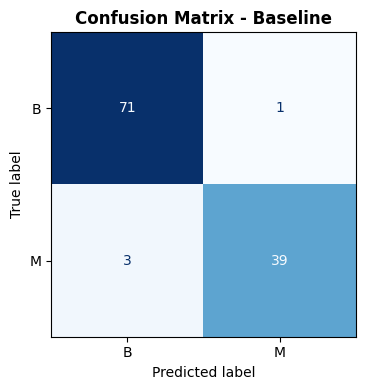

Đã xuất ma trận nhầm lẫn cho Baseline: D:\Adasync-Data-Mining\results\confusion_matrix_baseline.png


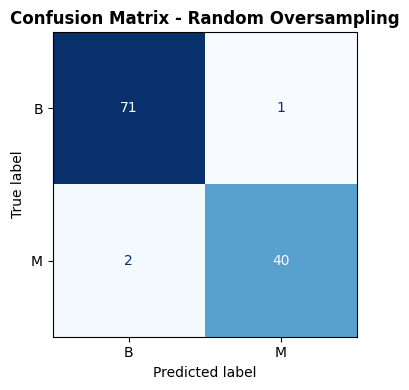

Đã xuất ma trận nhầm lẫn cho Random Oversampling: D:\Adasync-Data-Mining\results\confusion_matrix_random_oversampling.png


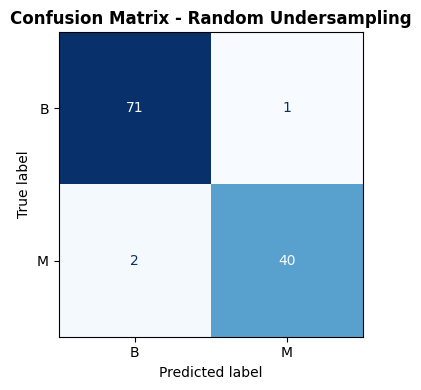

Đã xuất ma trận nhầm lẫn cho Random Undersampling: D:\Adasync-Data-Mining\results\confusion_matrix_random_undersampling.png


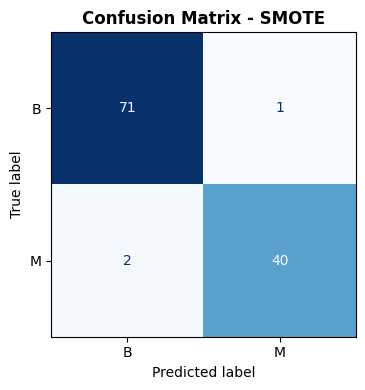

Đã xuất ma trận nhầm lẫn cho SMOTE: D:\Adasync-Data-Mining\results\confusion_matrix_smote.png


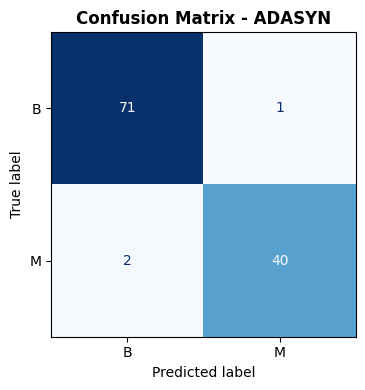

Đã xuất ma trận nhầm lẫn cho ADASYN: D:\Adasync-Data-Mining\results\confusion_matrix_adasyn.png


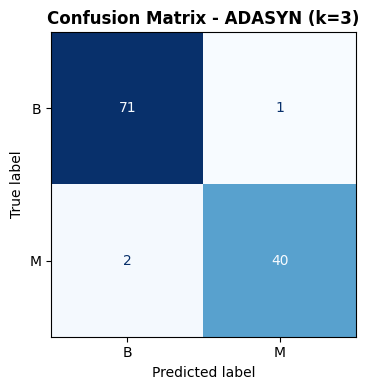

Đã xuất ma trận nhầm lẫn cho ADASYN (k=3): D:\Adasync-Data-Mining\results\confusion_matrix_adasyn_k=3.png


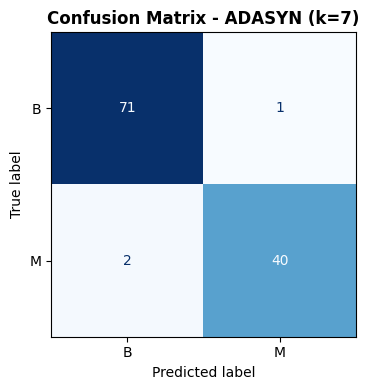

Đã xuất ma trận nhầm lẫn cho ADASYN (k=7): D:\Adasync-Data-Mining\results\confusion_matrix_adasyn_k=7.png


In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

RESULTS_DIR.mkdir(exist_ok=True)

def export_confusion_matrix(model, X_test, y_test, method_name):
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        display_labels=CONFUSION_MATRIX_LABELS,
        cmap="Blues",
        ax=ax,
        colorbar=False,
    )

    ax.set_title(f"Confusion Matrix - {method_name}", fontsize=12, fontweight="bold")
    output_path = RESULTS_DIR / f"confusion_matrix_{method_name.lower().replace(' ', '_').replace('(', '').replace(')', '')}.png"
    fig.tight_layout()
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Đã xuất ma trận nhầm lẫn cho {method_name}: {output_path}")

models_to_export = [
    ("Baseline", globals().get("baseline_model")),
    ("Random Oversampling", globals().get("ros_model")),
    ("Random Undersampling", globals().get("rus_model")),
    ("SMOTE", globals().get("smote_model")),
    ("ADASYN", globals().get("adasyn_model")),
    ("ADASYN (k=3)", globals().get("adasyn_model_k3")),
    ("ADASYN (k=7)", globals().get("adasyn_model_k7")),
]

for method_name, model in models_to_export:
    if model is None:
        print(f"⚠️ Bỏ qua {method_name}: Chưa tìm thấy model trong bộ nhớ!")
        continue
        
    export_confusion_matrix(model, X_test_processed, y_test, method_name)


Đã tính metrics trực tiếp từ các model Baseline, ROS, RUS, SMOTE và ADASYN.


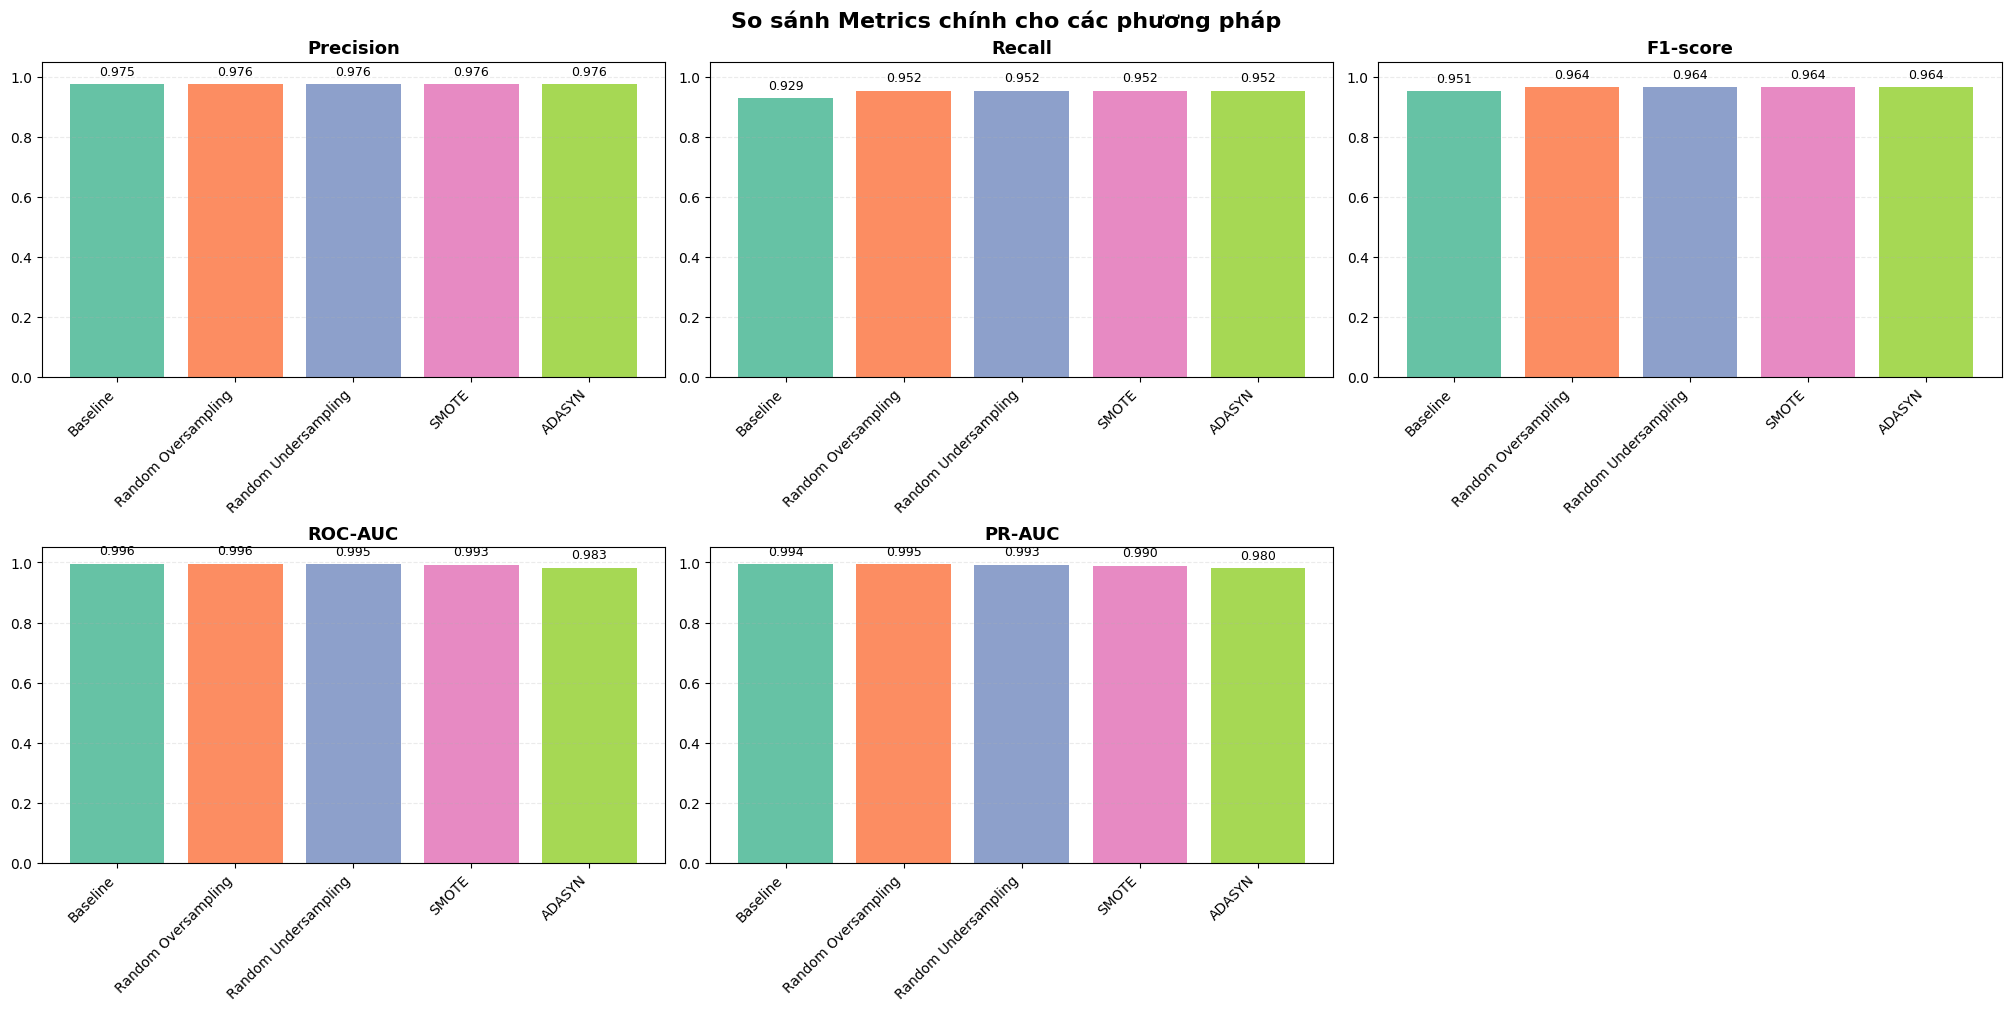

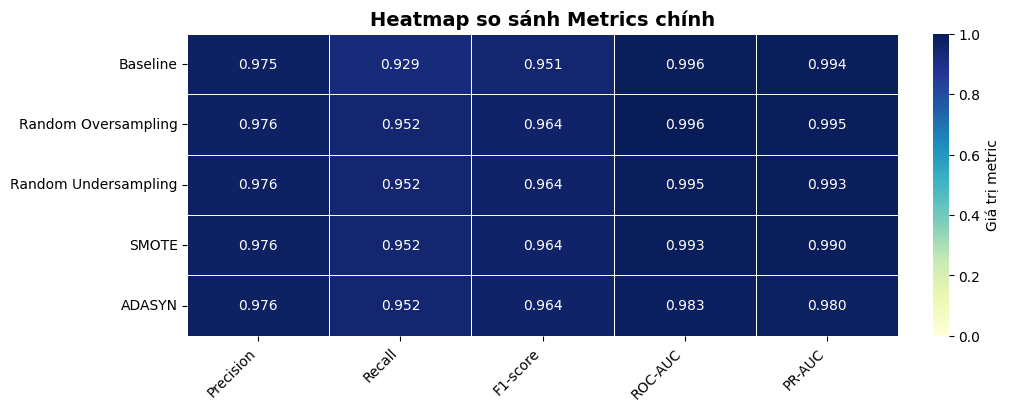

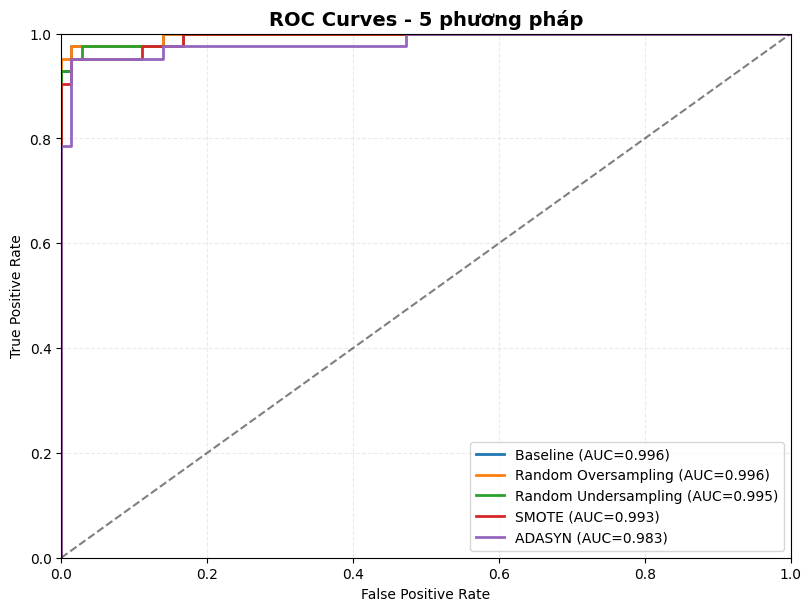

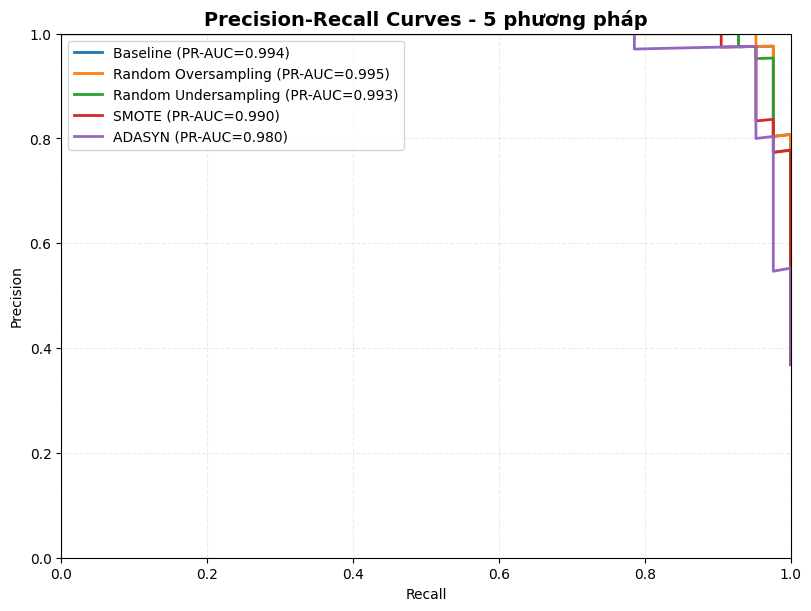

,Method,Precision,Recall,F1-score,ROC-AUC,PR-AUC
0,Baseline,0.9750,0.9286,0.9512,0.9960,0.9943
1,Random Oversampling,0.9756,0.9524,0.9639,0.9964,0.9949
2,Random Undersampling,0.9756,0.9524,0.9639,0.9950,0.9930
3,SMOTE,0.9756,0.9524,0.9639,0.9927,0.9896
4,ADASYN,0.9756,0.9524,0.9639,0.9831,0.9803


In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import seaborn as sns

RESULTS_DIR = Path(PROJECT_ROOT) / 'results' if 'PROJECT_ROOT' in globals() else Path.cwd() / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

selected_methods = ['Baseline', 'Random Oversampling', 'Random Undersampling', 'SMOTE', 'ADASYN']
metrics_path = RESULTS_DIR / 'metrics_comparison.csv'

if all(name in globals() for name in ['baseline_model', 'ros_model', 'rus_model', 'smote_model', 'adasyn_model']) and 'X_test_processed' in globals() and 'y_test' in globals():
    metrics_comparison = pd.DataFrame(
        [
            calculate_all_metrics_from_model(globals()[model_name], X_test_processed, y_test, method)
            for model_name, method in zip(['baseline_model', 'ros_model', 'rus_model', 'smote_model', 'adasyn_model'], selected_methods)
        ]
    )
    print("Đã tính metrics trực tiếp từ các model Baseline, ROS, RUS, SMOTE và ADASYN.")
elif metrics_path.exists():
    metrics_comparison = pd.read_csv(metrics_path)
    metrics_comparison = metrics_comparison[metrics_comparison['Method'].isin(selected_methods)].reset_index(drop=True)
    print(f"Đã đọc bảng metrics từ file: {metrics_path}")
else:
    raise NameError(
        'metrics_comparison chưa được định nghĩa và file metrics_comparison.csv không tồn tại. '
        'Hãy chạy lại các cell tạo model và xuất metrics trước khi vẽ biểu đồ.'
    )

metrics_comparison['Method'] = pd.Categorical(metrics_comparison['Method'], categories=selected_methods, ordered=True)
metrics_comparison = metrics_comparison.sort_values('Method').reset_index(drop=True)

methods = metrics_comparison['Method'].tolist()
metrics_to_plot = ['Precision', 'Recall', 'F1-score', 'ROC-AUC', 'PR-AUC']

# ===== 1. Bar charts for each metric =====
fig, axes = plt.subplots(2, 3, figsize=(20, 10), constrained_layout=True)
axes = axes.flatten()
for ax, metric in zip(axes[:5], metrics_to_plot):
    values = metrics_comparison[metric].values
    bars = ax.bar(range(len(methods)), values, color=sns.color_palette('Set2', len(methods)))
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.25, linestyle='--')
    ax.set_xticks(range(len(methods)))
    ax.set_xticklabels(methods, rotation=45, ha='right')
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, value + 0.02, f'{value:.3f}', ha='center', va='bottom', fontsize=9)

axes[5].set_visible(False)

plt.suptitle('So sánh Metrics chính cho các phương pháp', fontsize=16, fontweight='bold')
plt.savefig(RESULTS_DIR / 'metrics_comparison_chart.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# ===== 2. Heatmap for selected metrics =====
fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
heatmap_data = metrics_comparison.set_index('Method')[metrics_to_plot]
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlGnBu', vmin=0, vmax=1, cbar_kws={'label': 'Giá trị metric'}, linewidths=0.5, ax=ax)
ax.set_title('Heatmap so sánh Metrics chính', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=45, ha='right')
plt.savefig(RESULTS_DIR / 'metrics_comparison_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# ===== 3. ROC and PR curves for selected methods =====
if 'y_test_positive' not in globals():
    y_test_positive = (y_test == POSITIVE_CLASS).astype(int)

score_dict = {
    'Baseline': globals().get('baseline_y_score'),
    'Random Oversampling': globals().get('ros_y_score'),
    'Random Undersampling': globals().get('rus_y_score'),
    'SMOTE': globals().get('smote_y_score'),
    'ADASYN': globals().get('adasyn_y_score'),
}
models_scores = {name: score for name, score in score_dict.items() if score is not None}

if not models_scores:
    print('⚠️ Không tìm thấy biến score cho các model. Bỏ qua phần vẽ ROC và PR curves.')
else:
    fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
    for method_name, y_score in models_scores.items():
        fpr, tpr, _ = roc_curve(y_test_positive, y_score)
        ax.plot(fpr, tpr, lw=2, label=f'{method_name} (AUC={auc(fpr, tpr):.3f})')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    ax.set_title('ROC Curves - 5 phương pháp', fontsize=14, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.25, linestyle='--')
    ax.legend(loc='lower right')
    plt.savefig(RESULTS_DIR / 'roc_curves_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
    for method_name, y_score in models_scores.items():
        precision, recall, _ = precision_recall_curve(y_test_positive, y_score)
        ax.plot(recall, precision, lw=2, label=f'{method_name} (PR-AUC={auc(recall, precision):.3f})')
    ax.set_title('Precision-Recall Curves - 5 phương pháp', fontsize=14, fontweight='bold')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.25, linestyle='--')
    ax.legend(loc='best')
    plt.savefig(RESULTS_DIR / 'pr_curves_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

display(metrics_comparison)


## Phúc - Checklist chống data leakage

In [11]:
required_names = ["X_train", "X_test", "X_train_processed", "X_test_processed"]
missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise NameError(f"Thiếu biến để kiểm tra leakage: {missing_names}")

leakage_checks = build_leakage_checklist(
    X_train,
    X_test,
    X_train_processed,
    X_test_processed,
)

display(leakage_checks)
assert leakage_checks["passed"].all(), "Có checklist data leakage chưa đạt."
print("Checklist chống data leakage đạt")

,check,passed
0,Train/test indices are disjoint,True
1,Preprocessing kept train row count unchanged,True
2,Preprocessing kept test row count unchanged,True
3,Preprocessing kept train/test feature columns ...,True
4,"Test set is transformed only, not resampled",True


Checklist chống data leakage đạt


## Phúc - README, requirements và bàn giao khung notebook